<a href="https://colab.research.google.com/github/duck66-in/Model_learning/blob/main/Handbag_Shoe_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a Handbags-Shoes Classifier with Transfer Learning
Based on Deep Learning with Python by Francois Chollett
Introduction
In this Colab, we will first build a convolutional neural network from scratch.

We will then describe a very powerful technique called Transfer Learning that can be used to build highly accurate image classification models even when you have very little data. Pretty much any consumer-facing app that uses image AI was probably built using this technique.

We also show how to use a technique called data augmentation to effortlessly increase the size of your training dataset, and thereby achieve better accuracy.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as mp
import keras
from keras import losses
from keras import optimizers
from keras import ops
from keras.optimizers import schedules
from keras import metrics
from keras.applications.imagenet_utils import decode_predictions
import keras_hub

import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
from tensorflow import keras
from keras.layers import Dropout, Dense, GlobalAveragePooling1D, Flatten
import keras_hub

from keras import layers
from keras.layers import Lambda

import pandas as pd

keras.utils.set_random_seed(42)

In [3]:
!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
!unzip -qq handbags-shoes.zip

In [4]:
import os, shutil, pathlib
base_dir= pathlib.Path("/content/handbags-shoes")

In [11]:
for category in ('handbags', 'shoes'):
  fnames = os.listdir(base_dir/category)

  dir = base_dir/'train'/category
  os.makedirs(dir)
  for fname in fnames[:50]:   #first 50 samples go for training
    shutil.copyfile(src=base_dir/category/fname, dst = dir/fname)

  dir = base_dir/'validation'/category
  os.makedirs(dir)
  for fname in fnames[50:75]:   #nest 25 samples go for vaalidation
    shutil.copyfile(src=base_dir/category/fname, dst = dir/fname)

  dir = base_dir/'test'/category
  os.makedirs(dir)
  for fname in fnames[75:]:   # the remaining examples go into the test set
      shutil.copyfile(src=base_dir/category/fname,
                      dst=dir/fname)


The code above creates this directory structure:

train/
..handbags/
..shoes/
validation/
..handbags/
..shoes/
test/
..handbags/
..shoes/

When working with image JPEGs, we will follow this process:

Read in the JPEGs
Convert the JPEGs into tensors
Resize them to a standard size (since web-scraped images may be in different sizes)
Group them into batches (we’ll use batches of 32 images).
Fortunately, Keras gives us a single function that does all these in one shot! (Ref: image manipulation functions)

In [30]:
raw_train_dataset = keras.utils.image_dataset_from_directory(
    base_dir/'train',image_size= (224,224),batch_size=32
)

validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir/'validation',image_size= (224,224),batch_size=32
)
test_dataset = keras.utils.image_dataset_from_directory(
    base_dir/'test',image_size= (224,224),batch_size=32
)



Found 97 files belonging to 2 classes.
Found 49 files belonging to 2 classes.
Found 39 files belonging to 2 classes.


In [31]:
for images,_ in raw_train_dataset.take(1):
  print(images[0].shape)

(224, 224, 3)


In [32]:
# Number of classes
num_classes = 2  # Adjust to the number of classes in your dataset

# Preprocessing function for both images and labels
def preprocess_data(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.int32)      # Fix
    label = tf.one_hot(label, num_classes)  # Convert labels to one-hot
    return image, label


train_dataset = raw_train_dataset.map(preprocess_data)
validation_dataset = validation_dataset.map(preprocess_data)
test_dataset = test_dataset.map(preprocess_data)

# Debug to check shapes
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)  # Should be (32, 224, 224, 3)
    print("Label shape:", labels.shape)  # Should be (32, num_classes)

Image shape: (32, 224, 224, 3)
Label shape: (32, 2)


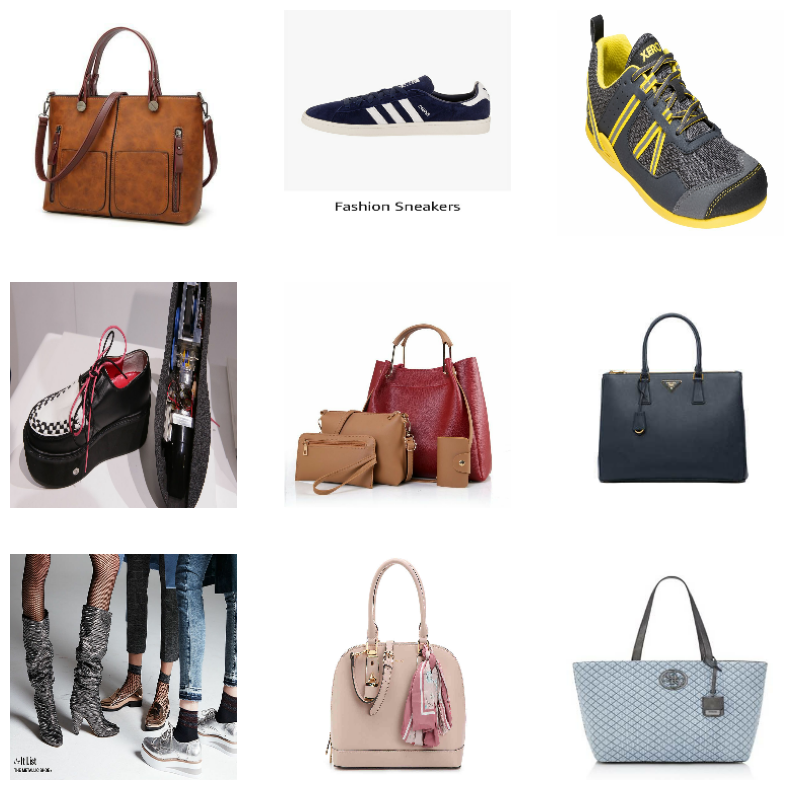

In [36]:
mp.figure(figsize=(10, 10))
for images, _ in raw_train_dataset.take(1):
    for i in range(9):
        ax = mp.subplot(3, 3, i + 1)
        mp.imshow(images[i].numpy().astype("uint8"))
        mp.axis("off")

In [37]:
patch_size = 16
image_size = 224

In [38]:
def get_patches(images, patch_size=16):
    input_shape = tf.shape(images) # Changed keras.ops.shape to tf.shape
    batch_size = input_shape[0]
    height = input_shape[1]
    width = input_shape[2]
    channels = input_shape[3]
    num_patches_h = height // patch_size
    num_patches_w = width // patch_size
    # key utility that breaks up an image into patches.
    # Returns batch_size x patch_index_i x patch_index_j x vectorized_patch_dimension
    patches = tf.image.extract_patches(images=images, # Added images= for clarity
                                      sizes=[1, patch_size, patch_size, 1],
                                      strides=[1, patch_size, patch_size, 1],
                                      rates=[1, 1, 1, 1],
                                      padding='VALID')
    # Using tf.reshape for consistency with other TensorFlow operations
    # Cast patches to float32 to ensure compatibility
    patches = tf.reshape(tf.cast(patches, dtype=tf.float32), # Cast patches to float32
        (
            batch_size,
            num_patches_h * num_patches_w,
            patch_size * patch_size * channels,
        ),
    )
    return patches


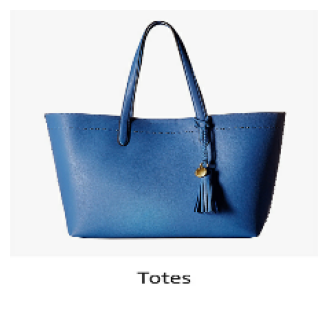

In [39]:
for images, _ in raw_train_dataset.take(1):
    mp.figure(figsize=(4, 4))
    resized_image = keras.ops.image.resize(
        keras.ops.convert_to_tensor([images[0]]), size=(image_size, image_size)
    )
    no_channels = keras.ops.shape(resized_image)[-1]

    mp.imshow(images[0].numpy().astype("uint8"))
    mp.axis("off")

Image size: 224 X 224
Patch size: 16 X 16
Patches per image: 196
Elements per patch: 768


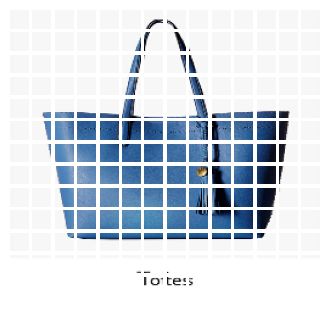

In [40]:
patches = get_patches(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
mp.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = mp.subplot(n, n, i + 1)
    patch_img = keras.ops.reshape(patch.numpy(), (16, 16, no_channels))
    mp.imshow(keras.ops.convert_to_numpy(patch_img).astype("uint8"))
    mp.axis("off")

In [41]:
#Recall num_patches is akin to the length of our context window
num_patches = (image_size // patch_size) ** 2

#Transformer dimensions
projection_dim = 64
num_heads = 8
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  #no. units in the feedforward portion of the tranfomers
num_transformer_layers = 2

#Classification head dimensions
mlp_head_units = [
    512,
    256,
]

num_classes = 2
input_shape = (image_size, image_size, 3)

In [42]:
inputs = keras.Input(shape=input_shape)

# Define data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
])
x = data_augmentation(inputs)

# Create patches.
patches = Lambda(get_patches, output_shape=(num_patches, patch_size * patch_size * 3))(x)

# Encode patches by projecting and then adding a position embedding
projection = layers.Dense(units=projection_dim)
position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
encoded_patches = projection(patches) + position_embedding(keras.ops.expand_dims(keras.ops.arange(start=0, stop=num_patches, step=1), axis=0))

# Create multiple layers of the Transformer block.
for _ in range(num_transformer_layers):
    # Layer normalization 1.
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    # Create a multi-head attention layer.
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)
    # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])
    # Layer normalization 2.
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    # MLP.
    for units in transformer_units:
        x3 = layers.Dense(units, activation=keras.activations.gelu)(x3)
        x3 = layers.Dropout(0.5)(x3)
    # Skip connection 2.
    encoded_patches = layers.Add()([x3, x2])


# Create a [batch_size, projection_dim] tensor.
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)

# Add MLP.
for units in mlp_head_units:
    representation = layers.Dense(units, activation=keras.activations.gelu)(representation)
    representation = layers.Dropout(0.5)(representation)

# Classify outputs.
logits = layers.Dense(num_classes)(representation)

# Create the Keras model.
model = keras.Model(inputs=inputs, outputs=logits)

In [43]:
optimizer = keras.optimizers.AdamW(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
    ],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 768)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 64)   │     49,216 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,903,234 (26.33 MB)

 Trainable params: 6,903,234 (26.33 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Before calling fit, build the model with a sample input:
sample_input = tf.zeros((32, image_size, image_size, 3))
model(sample_input)  # Build the model


history = model.fit(
    train_dataset,  # Replace with your dataset
    validation_data=validation_dataset,
    epochs=40,  # Train for a few epochs initially
    batch_size=32
)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.3951 - loss: 5.2038 - val_accuracy: 0.4898 - val_loss: 2.4390
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5509 - loss: 3.2886 - val_accuracy: 0.4898 - val_loss: 6.4766
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5488 - loss: 6.1503 - val_accuracy: 0.4898 - val_loss: 3.6557
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4263 - loss: 7.3562 - val_accuracy: 0.5918 - val_loss: 0.6187
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4554 - loss: 4.8122 - val_accuracy: 0.5102 - val_loss: 2.8646
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4979 - loss: 5.3499 - val_accuracy: 0.4898 - val_loss: 1.4669
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4368 - loss: 4.5835 - val_accuracy: 0.6122 - val_loss: 0.7304
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5518 - loss: 3.7418 - val_accuracy: 0.4898 - val_loss: 3.5101
Epoch 9/40
4

In [45]:
# Load the ViT backbone and preprocessor
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Define data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
])

# Create the custom model
inputs = keras.Input(shape=(224, 224, 3))  # Input shape for the images
x = data_augmentation(inputs)              # Apply data augmentation
x = preprocessor(x)                   # Preprocess inputs for ViT
x = backbone(x, training=True)             # Pass through the ViT backbone
x = Flatten()(x)                           # Flatten the ViT outputs
x = Dense(backbone.hidden_dim, activation="linear")(x)  # Project down to the hidden dimension
x = Dropout(0.5)(x)                        # Add dropout for regularization
x = Dense(256, activation="relu")(x)       # Add a dense layer for feature learning
x = Dropout(0.5)(x)                        # Another dropout layer
outputs = Dense(2, activation="softmax")(x)  # Final classification layer

# Create the model
model = keras.Model(inputs, outputs)

# Summary of the model
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 151296)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 768)            │   116,196,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,192,130 (771.30 MB)

 Trainable params: 202,192,130 (771.30 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Freeze the backbone initially
backbone.trainable = False

# Compile the model for initial training
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train only the classification head
history = model.fit(
    train_dataset,  # Replace with your dataset
    validation_data=validation_dataset,
    epochs=2,  # Train for a few epochs initially
    batch_size=32
)

Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 158s 37s/step - accuracy: 0.4242 - loss: 24.0409 - val_accuracy: 0.5102 - val_loss: 22.5097
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 178s 49s/step - accuracy: 0.4077 - loss: 20.3877 - val_accuracy: 0.5102 - val_loss: 4.0845


In [47]:
model.evaluate(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 44s 7s/step - accuracy: 0.4535 - loss: 4.4182


[4.338439464569092, 0.4615384638309479]

In [49]:
input = keras.Input(shape=(224,224,3))

# we normalize "inside" the model with a Rescaling layer
# so that we don't have to remember to do it every time
# we need to use the model to make a prediction
h = keras.layers.Rescaling(1./255)(input)


# first convolutional block
h = keras.layers.Conv2D(32,                    # the number of filters
                        kernel_size=(2, 2),    # the shape of each filter
                        activation="relu",
                        name="Conv_1")(h)
h = keras.layers.MaxPool2D()(h)


# second convolutional block
h = keras.layers.Conv2D(32,                    # the number of filters
                        kernel_size=(2, 2),    # the shape of each filter
                        activation="relu",
                        name="Conv_2")(h)
h = keras.layers.MaxPool2D()(h)

# flatten layer
h = keras.layers.Flatten()(h)

# output layer
output = keras.layers.Dense(1, activation="sigmoid")(h)

model = keras.Model(input, output)

In [50]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │        96,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,345 (395.88 KB)

 Trainable params: 101,345 (395.88 KB)

 Non-trainable params: 0 (0.00 B)

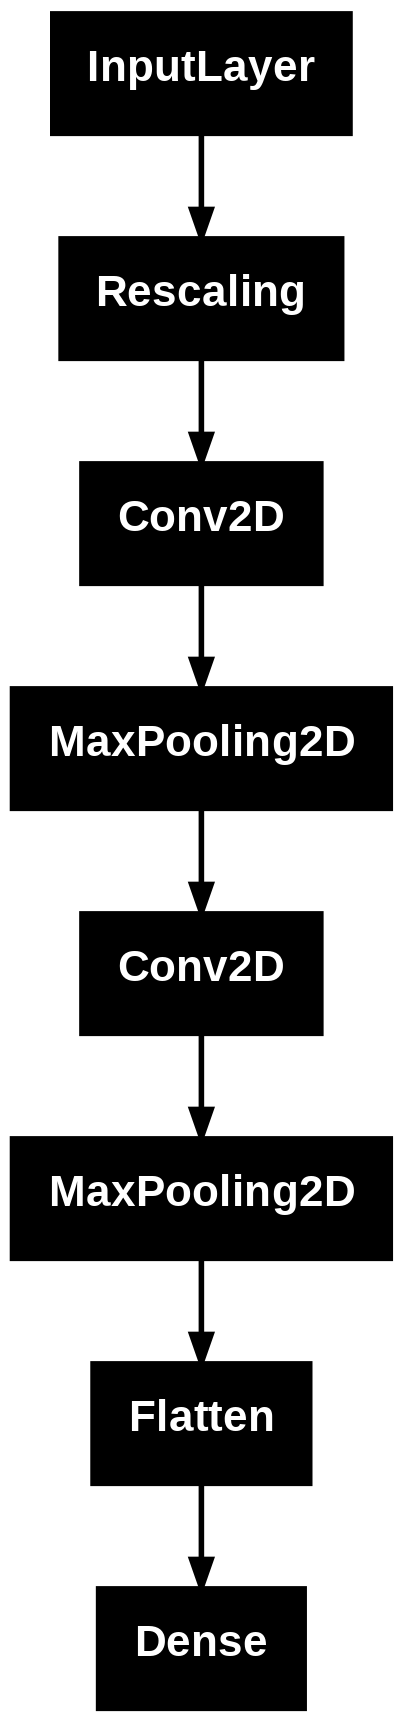

In [51]:
keras.utils.plot_model(model)

In [52]:
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [57]:
for images, labels in train_dataset.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32, 2)


In [59]:
history = model.fit(
    train_dataset,  # Replace with your dataset
    validation_data=validation_dataset,
    epochs=2,  # Train for a few epochs initially
    batch_size=32
)

Epoch 1/2


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.